# Problem 3 — GRU Rolling Baseline — Fixed for FILT. NTU Forecasting

本 notebook 是第三题的 **GRU rolling single-step baseline**。

核心变化：

- 训练时只做 **单步预测**：用过去 24 小时预测下一步 `FILT. NTU`
- 预测未来 12 小时时采用 **滚动预测**：
  1. 先预测未来 2 小时
  2. 把该预测值写回下一步输入序列中的 `FILT. NTU`
  3. 再预测未来 4 小时
  4. 依次滚动到未来 12 小时

保持不变：

- 目标变量：`FILT. NTU`
- 数据间隔：理论上为 2 小时
- 输入窗口：过去 12 个观测点，即约过去 24 小时
- 预测输出：未来 2h、4h、6h、8h、10h、12h
- 特征集合不变
- 分块时间序列划分不变
- 指定日期输出与敏感性分析保留

> 题目要求未来 1–12 小时预测，但原始数据为 2 小时采样，因此本 baseline 将其离散化为未来 2、4、6、8、10、12 小时六步预测问题。

In [2]:
# =========================
# 0. Global configuration
# =========================

from pathlib import Path

POSSIBLE_DATA_PATHS = [
    Path("data/merged.xlsx"),
    Path("merged.xlsx"),
    Path("../data/merged.xlsx"),
]

OUTPUT_DIR = Path("outputs/problem3/gru_rolling_baseline_v3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Manual override. Keep as None unless automatic datetime detection fails.
MANUAL_DATETIME_COL = None
MANUAL_DATE_COL = None
MANUAL_TIME_COL = None

# For Problem 3, date-only data are invalid because the task requires hourly prediction.
ALLOW_DATE_ONLY = False

TARGET = "FILT. NTU"

REQUIRED_RAW_COLS = [
    "R/W NTU",
    "R/W PH",
    "ALUM",
    "F/RIDE",
    "R/W FLOW",
    TARGET,
]

FEATURES = [
    "R/W NTU",
    "RW_PH_10POWER_STD",
    "AL_DOSE",
    "FRIDE_ABNORMAL",
    "R/W FLOW",
    "FILT. NTU",
]

LOOKBACK = 12       # 12 records = approximately past 24 hours
HORIZON = 6         # rolling output length: next 2h, 4h, ..., 12h
HORIZON_HOURS = [2, 4, 6, 8, 10, 12]
EXPECTED_FREQ_HOURS = 2

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 12
LEARNING_RATE = 1e-3

HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.0

# Rolling mode: the model is trained for one-step prediction only.
MODEL_OUTPUT_SIZE = 1

# During rolling prediction, future exogenous features are taken from their future rows when available,
# while future FILT. NTU is replaced by the model prediction.
# If a future row is unavailable, the last input feature vector is carried forward.
ROLLING_EXOG_MODE = "known_future"  # options: "known_future", "carry_forward"

SEED = 42

REQUESTED_DATES = ["2026-02-01", "2026-02-10", "2026-02-20"]
REQUESTED_TIMES = ["07:00", "09:00", "11:00", "13:00", "15:00", "17:00", "19:00"]

# If exact 07:00 is not on the 2-hour grid, this notebook also generates native-grid predictions.
NATIVE_GRID_START_TIME = "07:00"
NATIVE_BASE_TOLERANCE_HOURS = 1.1

# Sequence construction.
# If the strict 2-hour continuity check creates no samples, the notebook falls back to chronological row-order sequences.
USE_GAP_AWARE_SEQUENCES = True
ALLOW_ROW_ORDER_FALLBACK = True

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes\outputs\problem3\gru_rolling_baseline_v3


In [3]:
# =========================
# 1. Imports and seed control
# =========================

import os
import math
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 2. Load data and reconstruct datetime

这个版本会优先尝试：

```text
DATE column + TIME column
```

避免只读到日期列，导致所有时间都变成 `00:00`。

如果自动识别仍然失败，可以手动设置：

```python
MANUAL_DATE_COL = "your_date_column"
MANUAL_TIME_COL = "your_time_column"
```

或者：

```python
MANUAL_DATETIME_COL = "your_datetime_column"
```

In [4]:
# =========================
# 2. Load data and robust datetime reconstruction
# =========================

def find_data_path(possible_paths):
    for p in possible_paths:
        if p.exists():
            return p
    raise FileNotFoundError(
        "merged.xlsx not found. Please put the file at one of: "
        + ", ".join(str(p) for p in possible_paths)
    )

def parse_excel_or_regular_date(s: pd.Series) -> pd.Series:
    """
    Parse date column. Supports normal date strings/datetime and Excel serial dates.
    """
    numeric = pd.to_numeric(s, errors="coerce")
    numeric_valid = numeric.notna().mean()

    # Excel serial date is usually around 40000-50000.
    if numeric_valid >= 0.70:
        values = numeric.dropna()
        if len(values) > 0 and values.between(20000, 60000).mean() >= 0.70:
            return pd.to_datetime(numeric, unit="D", origin="1899-12-30", errors="coerce")

    return pd.to_datetime(s, errors="coerce")

def parse_time_to_timedelta(s: pd.Series) -> pd.Series:
    """
    Convert a time column into timedelta from midnight.

    Supported formats:
    - Excel time fraction, e.g. 0.2916667 = 07:00
    - Numeric hour, e.g. 7, 7.5, 14
    - HHMM integer, e.g. 700, 730, 1530
    - datetime.time or string, e.g. 07:00, 7:00:00
    """
    numeric = pd.to_numeric(s, errors="coerce")
    if numeric.notna().mean() >= 0.70:
        vals = numeric.dropna()
        if len(vals) > 0:
            min_v, max_v = vals.min(), vals.max()

            # Excel time fraction: [0, 1)
            if min_v >= 0 and max_v <= 1:
                return pd.to_timedelta(numeric, unit="D")

            # Numeric hour: [0, 24]
            if min_v >= 0 and max_v <= 24:
                return pd.to_timedelta(numeric, unit="h")

            # HHMM format, e.g. 700, 730, 1530
            if min_v >= 0 and max_v <= 2359:
                as_int = numeric.round().astype("Int64")
                hours = (as_int // 100).astype("float")
                minutes = (as_int % 100).astype("float")
                valid = (hours >= 0) & (hours <= 23) & (minutes >= 0) & (minutes <= 59)
                out = pd.Series(pd.NaT, index=s.index, dtype="timedelta64[ns]")
                out.loc[valid] = (
                    pd.to_timedelta(hours.loc[valid], unit="h") +
                    pd.to_timedelta(minutes.loc[valid], unit="m")
                )
                if out.notna().mean() >= 0.70:
                    return out

    # Object / string / datetime-like time
    text = s.astype(str).str.strip()
    parsed = pd.to_datetime(text, errors="coerce")
    out = (
        pd.to_timedelta(parsed.dt.hour, unit="h") +
        pd.to_timedelta(parsed.dt.minute, unit="m") +
        pd.to_timedelta(parsed.dt.second, unit="s")
    )
    return out

def build_datetime_column(df: pd.DataFrame):
    """
    Robust datetime reconstruction.

    Priority:
    1. Manual full datetime column.
    2. Manual date + time columns.
    3. Auto-detected date + time columns.
    4. Strong full datetime column.
    5. Fallback parseable column.
    """
    cols = list(df.columns)
    upper_map = {c: str(c).upper().strip() for c in cols}

    # 1. Manual full datetime column
    if MANUAL_DATETIME_COL is not None:
        if MANUAL_DATETIME_COL not in df.columns:
            raise KeyError(f"MANUAL_DATETIME_COL not found: {MANUAL_DATETIME_COL}")
        parsed = pd.to_datetime(df[MANUAL_DATETIME_COL], errors="coerce")
        if parsed.notna().mean() < 0.70:
            raise ValueError(f"Manual datetime column cannot be parsed: {MANUAL_DATETIME_COL}")
        return parsed, MANUAL_DATETIME_COL

    # 2. Manual DATE + TIME
    if MANUAL_DATE_COL is not None and MANUAL_TIME_COL is not None:
        if MANUAL_DATE_COL not in df.columns:
            raise KeyError(f"MANUAL_DATE_COL not found: {MANUAL_DATE_COL}")
        if MANUAL_TIME_COL not in df.columns:
            raise KeyError(f"MANUAL_TIME_COL not found: {MANUAL_TIME_COL}")
        date_part = parse_excel_or_regular_date(df[MANUAL_DATE_COL]).dt.normalize()
        time_delta = parse_time_to_timedelta(df[MANUAL_TIME_COL])
        combined = date_part + time_delta
        if combined.notna().mean() < 0.70:
            raise ValueError(f"Manual DATE + TIME cannot be parsed: {MANUAL_DATE_COL} + {MANUAL_TIME_COL}")
        return combined, f"{MANUAL_DATE_COL} + {MANUAL_TIME_COL}"

    # 3. Auto-detect DATE + TIME first
    date_keywords = ["DATE", "日期", "DAY", "日"]
    time_keywords = ["TIME", "时间", "HOUR", "小时", "时刻"]

    date_cols = [
        c for c in cols
        if any(k in upper_map[c] for k in date_keywords)
    ]
    time_cols = [
        c for c in cols
        if any(k in upper_map[c] for k in time_keywords)
    ]

    candidate_combinations = []
    for d in date_cols:
        for t in time_cols:
            if d == t:
                continue
            date_part = parse_excel_or_regular_date(df[d]).dt.normalize()
            time_delta = parse_time_to_timedelta(df[t])
            combined = date_part + time_delta
            valid_rate = combined.notna().mean()
            unique_times = combined.dropna().dt.strftime("%H:%M").nunique()
            candidate_combinations.append((valid_rate, unique_times, d, t, combined))

    # Prefer high valid rate and more than one time-of-day.
    candidate_combinations = sorted(candidate_combinations, key=lambda x: (x[0], x[1]), reverse=True)
    for valid_rate, unique_times, d, t, combined in candidate_combinations:
        if valid_rate >= 0.70 and unique_times > 1:
            return combined, f"{d} + {t}"

    # If no multi-time combination exists, still use date+time if valid.
    for valid_rate, unique_times, d, t, combined in candidate_combinations:
        if valid_rate >= 0.70:
            return combined, f"{d} + {t}"

    # 4. Strong full-datetime candidates
    strong_keywords = ["DATETIME", "DATE_TIME", "TIMESTAMP", "TIME_STAMP", "DATE/TIME", "日期时间"]
    for c in cols:
        name = upper_map[c]
        if any(k in name for k in strong_keywords):
            parsed = pd.to_datetime(df[c], errors="coerce")
            if parsed.notna().mean() >= 0.70:
                return parsed, c

    # 5. Fallback: any parseable column
    fallback_candidates = []
    for c in cols:
        parsed = pd.to_datetime(df[c], errors="coerce")
        valid_rate = parsed.notna().mean()
        if valid_rate >= 0.70:
            unique_times = parsed.dropna().dt.strftime("%H:%M").nunique()
            fallback_candidates.append((valid_rate, unique_times, c, parsed))

    fallback_candidates = sorted(fallback_candidates, key=lambda x: (x[0], x[1]), reverse=True)
    if fallback_candidates:
        valid_rate, unique_times, c, parsed = fallback_candidates[0]
        return parsed, c

    raise ValueError("Cannot detect datetime column. Please set MANUAL_DATE_COL and MANUAL_TIME_COL.")

def validate_datetime_resolution(df: pd.DataFrame, datetime_col="DATETIME"):
    dt = pd.to_datetime(df[datetime_col])
    unique_time_count = dt.dt.strftime("%H:%M").nunique()
    most_common_diffs = dt.sort_values().diff().value_counts().head(5)

    print("Unique time-of-day count:", unique_time_count)
    print("\nMost common time differences:")
    display(most_common_diffs.to_frame("count"))

    if unique_time_count <= 1 and not ALLOW_DATE_ONLY:
        print("\nDetected columns:")
        print(df.columns.tolist())
        print("\nColumns likely related to date/time:")
        for c in df.columns:
            upper = str(c).upper()
            if any(k in upper for k in ["DATE", "TIME", "HOUR", "日期", "时间", "时"]):
                print(f"\nColumn: {c}")
                display(df[[c]].head(20))

        raise ValueError(
            "DATETIME appears to be date-only: all rows have the same time-of-day. "
            "For Problem 3, you need a 2-hour timestamp. "
            "Set MANUAL_DATE_COL and MANUAL_TIME_COL in Cell 0, then rerun."
        )

data_path = find_data_path(POSSIBLE_DATA_PATHS)
print("Reading:", data_path.resolve())

data = pd.read_excel(data_path)
data.columns = [str(c).strip() for c in data.columns]

dt, dt_source = build_datetime_column(data)
data["DATETIME"] = dt

data = (
    data.dropna(subset=["DATETIME"])
        .sort_values("DATETIME")
        .drop_duplicates(subset=["DATETIME"], keep="first")
        .reset_index(drop=True)
)

print("Datetime source:", dt_source)
print("Shape:", data.shape)
print("Time range:", data["DATETIME"].min(), "to", data["DATETIME"].max())

validate_datetime_resolution(data, "DATETIME")

print("\nFirst 30 timestamps:")
display(data["DATETIME"].dt.strftime("%Y-%m-%d %H:%M").head(30))

print("\nTime-of-day distribution:")
display(data["DATETIME"].dt.strftime("%H:%M").value_counts().sort_index().to_frame("count"))

print("\nColumns:")
print(data.columns.tolist())

data.head()

Reading: E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
Datetime source: DATE + TIME
Shape: (5460, 19)
Time range: 2025-01-01 07:00:00 to 2026-04-01 05:00:00
Unique time-of-day count: 12

Most common time differences:


,count
DATETIME,
0 days 02:00:00,5459



First 30 timestamps:


0     2025-01-01 07:00
1     2025-01-01 09:00
2     2025-01-01 11:00
3     2025-01-01 13:00
4     2025-01-01 15:00
5     2025-01-01 17:00
6     2025-01-01 19:00
7     2025-01-01 21:00
8     2025-01-01 23:00
9     2025-01-02 01:00
10    2025-01-02 03:00
11    2025-01-02 05:00
12    2025-01-02 07:00
13    2025-01-02 09:00
14    2025-01-02 11:00
15    2025-01-02 13:00
16    2025-01-02 15:00
17    2025-01-02 17:00
18    2025-01-02 19:00
19    2025-01-02 21:00
20    2025-01-02 23:00
21    2025-01-03 01:00
22    2025-01-03 03:00
23    2025-01-03 05:00
24    2025-01-03 07:00
25    2025-01-03 09:00
26    2025-01-03 11:00
27    2025-01-03 13:00
28    2025-01-03 15:00
29    2025-01-03 17:00
Name: DATETIME, dtype: str


Time-of-day distribution:


,count
DATETIME,
01:00,455
03:00,455
05:00,455
07:00,455
09:00,455
11:00,455
13:00,455
15:00,455
17:00,455



Columns:
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW', 'DATETIME']


,DATE,TIME,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,C/W WELL LEVEL,PH,NTU,CLR,CL2,F/RIDE,ALUM,T/W PUMP DUTY,T/W FLOW,DATETIME
0,2025-01-01,07:00:00,6.22,1.0,45.3,150,850.0,7.0,0.04,3.82,7.2,0.12,5.0,1.5,0.0,0.04,2.0,42.6,2025-01-01 07:00:00
1,2025-01-01,09:00:00,6.34,1.0,45.2,120,830.0,7.0,0.05,3.81,7.2,0.12,5.0,1.5,0.0,0.04,2.0,42.6,2025-01-01 09:00:00
2,2025-01-01,11:00:00,6.17,1.0,44.9,82,780.0,7.0,0.05,3.81,7.2,0.12,5.0,1.6,0.0,0.04,2.0,42.7,2025-01-01 11:00:00
3,2025-01-01,13:00:00,5.99,1.0,44.9,62,720.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,0.0,0.04,2.0,42.3,2025-01-01 13:00:00
4,2025-01-01,15:00:00,5.83,1.0,44.5,56,641.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,0.0,0.04,2.0,42.5,2025-01-01 15:00:00


## 3. Basic data audit

检查必要变量是否存在、缺失值情况、时间间隔是否基本为 2 小时。

In [5]:
# =========================
# 3. Data audit
# =========================

missing_cols = [c for c in REQUIRED_RAW_COLS if c not in data.columns]
if missing_cols:
    raise KeyError(
        "Missing required columns: "
        + str(missing_cols)
        + "\nPlease check column names in merged.xlsx."
    )

print("Required raw columns exist.")

for c in REQUIRED_RAW_COLS:
    data[c] = pd.to_numeric(data[c], errors="coerce")

missing_report = data[REQUIRED_RAW_COLS].isna().sum().sort_values(ascending=False)
print("\nMissing values before filling:")
display(missing_report.to_frame("missing_count"))

time_diff = data["DATETIME"].diff()
gap_report = time_diff.value_counts().head(10)
print("\nMost common time differences:")
display(gap_report.to_frame("count"))

large_gaps = data.loc[time_diff > pd.Timedelta(hours=EXPECTED_FREQ_HOURS * 1.5), ["DATETIME"]].copy()
print(f"\nNumber of gaps larger than {EXPECTED_FREQ_HOURS * 1.5:.1f} hours:", len(large_gaps))
if len(large_gaps) > 0:
    display(large_gaps.head(10))

Required raw columns exist.

Missing values before filling:


,missing_count
R/W PH,1644
ALUM,1644
R/W NTU,0
F/RIDE,0
R/W FLOW,0
FILT. NTU,0



Most common time differences:


,count
DATETIME,
0 days 02:00:00,5459



Number of gaps larger than 3.0 hours: 0


## 4. Preprocessing and physical feature construction

构造第三题 GRU baseline 使用的物理特征：

```text
FRIDE_CLEAN = F/RIDE, if 0 < F/RIDE <= 0.01
FRIDE_CLEAN = 0,     if F/RIDE = 0 or F/RIDE > 0.01

AL_DOSE = 56.9 × ALUM + 81.0 × FRIDE_CLEAN

FRIDE_ABNORMAL = 1(F/RIDE > 0.01)
```

pH 变换先构造未标准化版本：

```text
RW_PH_10POWER = 10 ^ (R/W PH)
```

后面按时间分块后，只用训练集计算 pH 的 mean/std，生成：

```text
RW_PH_10POWER_STD
```

In [6]:
# =========================
# 4. Preprocessing
# =========================

data_pre = data.copy()

# Missing F/RIDE is treated as 0 for this baseline.
data_pre["F/RIDE"] = data_pre["F/RIDE"].fillna(0)

# Interpolate continuous variables.
# If strict raw-only evaluation is required, remove missing-target rows instead.
continuous_cols = ["R/W NTU", "R/W PH", "ALUM", "R/W FLOW", TARGET]
for c in continuous_cols:
    data_pre[c] = (
        data_pre[c]
        .interpolate(method="linear", limit_direction="both")
        .ffill()
        .bfill()
    )

data_pre["FRIDE_CLEAN"] = data_pre["F/RIDE"].where(
    (data_pre["F/RIDE"] > 0) & (data_pre["F/RIDE"] <= 0.01),
    0.0
)

data_pre["FRIDE_ABNORMAL"] = (data_pre["F/RIDE"] > 0.01).astype(int)

data_pre["AL_DOSE"] = (
    56.9 * data_pre["ALUM"] + 
    81.0 * data_pre["FRIDE_CLEAN"]
)

# pH transform.
# pH outside [0, 14] is clipped only for numerical stability.
ph_invalid_count = ((data_pre["R/W PH"] < 0) | (data_pre["R/W PH"] > 14)).sum()
print("Invalid pH count outside [0, 14]:", ph_invalid_count)

ph_for_power = data_pre["R/W PH"].clip(lower=0, upper=14)
data_pre["RW_PH_10POWER"] = 10.0 ** ph_for_power

check_cols = REQUIRED_RAW_COLS + ["FRIDE_CLEAN", "FRIDE_ABNORMAL", "AL_DOSE", "RW_PH_10POWER"]
print("\nMissing values after preprocessing:")
display(data_pre[check_cols].isna().sum().to_frame("missing_count"))

data_pre[["DATETIME"] + check_cols].head()

Invalid pH count outside [0, 14]: 0

Missing values after preprocessing:


,missing_count
R/W NTU,0
R/W PH,0
ALUM,0
F/RIDE,0
R/W FLOW,0
FILT. NTU,0
FRIDE_CLEAN,0
FRIDE_ABNORMAL,0
AL_DOSE,0
RW_PH_10POWER,0


,DATETIME,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW,FILT. NTU,FRIDE_CLEAN,FRIDE_ABNORMAL,AL_DOSE,RW_PH_10POWER
0,2025-01-01 07:00:00,150,7.0,0.04,0.0,45.3,0.04,0.0,0,2.276,10000000.0
1,2025-01-01 09:00:00,120,7.0,0.04,0.0,45.2,0.05,0.0,0,2.276,10000000.0
2,2025-01-01 11:00:00,82,7.0,0.04,0.0,44.9,0.05,0.0,0,2.276,10000000.0
3,2025-01-01 13:00:00,62,7.0,0.04,0.0,44.9,0.05,0.0,0,2.276,10000000.0
4,2025-01-01 15:00:00,56,7.0,0.04,0.0,44.5,0.05,0.0,0,2.276,10000000.0


## 5. Chronological block split

按时间顺序分块：

- 前 70%：训练集
- 中间 15%：验证集
- 最后 15%：测试集

不 shuffle，避免未来信息泄漏。

In [7]:
# =========================
# 5. Chronological split
# =========================

n = len(data_pre)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = data_pre.iloc[:train_end].copy().reset_index(drop=True)
val_df = data_pre.iloc[train_end:val_end].copy().reset_index(drop=True)
test_df = data_pre.iloc[val_end:].copy().reset_index(drop=True)

print("Total rows:", n)
print("Train rows:", len(train_df), train_df["DATETIME"].min(), "to", train_df["DATETIME"].max())
print("Val rows:  ", len(val_df), val_df["DATETIME"].min(), "to", val_df["DATETIME"].max())
print("Test rows: ", len(test_df), test_df["DATETIME"].min(), "to", test_df["DATETIME"].max())

# Standardize transformed pH using training block only.
ph_mean = train_df["RW_PH_10POWER"].mean()
ph_std = train_df["RW_PH_10POWER"].std()

for df in [train_df, val_df, test_df]:
    df["RW_PH_10POWER_STD"] = (df["RW_PH_10POWER"] - ph_mean) / (ph_std + 1e-8)

full_df = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)

print("\npH train mean/std for 10^pH:")
print("mean =", ph_mean)
print("std  =", ph_std)

print("\nFinal FEATURES:")
print(FEATURES)
display(full_df[["DATETIME"] + FEATURES].head())

Total rows: 5460
Train rows: 3821 2025-01-01 07:00:00 to 2025-11-15 15:00:00
Val rows:   820 2025-11-15 17:00:00 to 2026-01-22 23:00:00
Test rows:  819 2026-01-23 01:00:00 to 2026-04-01 05:00:00

pH train mean/std for 10^pH:
mean = 10130678.265229171
std  = 583567.5154086379

Final FEATURES:
['R/W NTU', 'RW_PH_10POWER_STD', 'AL_DOSE', 'FRIDE_ABNORMAL', 'R/W FLOW', 'FILT. NTU']


,DATETIME,R/W NTU,RW_PH_10POWER_STD,AL_DOSE,FRIDE_ABNORMAL,R/W FLOW,FILT. NTU
0,2025-01-01 07:00:00,150,-0.22393,2.276,0,45.3,0.04
1,2025-01-01 09:00:00,120,-0.22393,2.276,0,45.2,0.05
2,2025-01-01 11:00:00,82,-0.22393,2.276,0,44.9,0.05
3,2025-01-01 13:00:00,62,-0.22393,2.276,0,44.9,0.05
4,2025-01-01 15:00:00,56,-0.22393,2.276,0,44.5,0.05


## 6. Fit scalers using training block only

GRU 对变量尺度敏感。因此：

- `feature_scaler` 只在训练集输入特征上 fit
- `target_scaler` 只在训练集目标变量上 fit
- 验证集、测试集和指定日期预测都使用同一套训练集 scaler transform

In [8]:
# =========================
# 6. Scaling
# =========================

for c in FEATURES:
    if c not in train_df.columns:
        raise KeyError(f"Feature {c} not found. Please check preprocessing order.")

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(train_df[FEATURES])
target_scaler.fit(train_df[[TARGET]])

def scale_block(df: pd.DataFrame) -> pd.DataFrame:
    out = df[["DATETIME"]].copy()
    out[FEATURES] = feature_scaler.transform(df[FEATURES])
    out["TARGET_SCALED"] = target_scaler.transform(df[[TARGET]]).reshape(-1)
    return out

train_scaled = scale_block(train_df)
val_scaled = scale_block(val_df)
test_scaled = scale_block(test_df)
full_scaled = scale_block(full_df)

print("Scaled train preview:")
display(train_scaled.head())

Scaled train preview:


,DATETIME,R/W NTU,RW_PH_10POWER_STD,AL_DOSE,FRIDE_ABNORMAL,R/W FLOW,FILT. NTU,TARGET_SCALED
0,2025-01-01 07:00:00,4.569933,-0.223959,-2.551798,-0.137598,-1.012748,-0.260802,-0.260802
1,2025-01-01 09:00:00,3.398396,-0.223959,-2.551798,-0.137598,-1.041661,-0.245276,-0.245276
2,2025-01-01 11:00:00,1.914450,-0.223959,-2.551798,-0.137598,-1.128402,-0.245276,-0.245276
3,2025-01-01 13:00:00,1.133426,-0.223959,-2.551798,-0.137598,-1.128402,-0.245276,-0.245276
4,2025-01-01 15:00:00,0.899118,-0.223959,-2.551798,-0.137598,-1.244056,-0.245276,-0.245276


## 7. Build GRU sequences for single-step training

训练样本构造方式：

```text
X_t = [x_{t-11}, ..., x_t]
y_t = FILT.NTU_{t+1}
```

即模型只学习：

```text
过去 24 小时序列 → 下一步 FILT. NTU
```

为了后续评估未来 2–12 小时滚动预测，构造样本时同时保留真实未来六步标签：

```text
y_multi_t = [FILT.NTU_{t+1}, ..., FILT.NTU_{t+6}]
```

默认优先使用 gap-aware 构造方式：如果时间缺口大于 3 小时，则不跨缺口构造序列。  
如果 strict gap-aware 构造后没有足够样本，本 notebook 会自动 fallback 到按时间排序后的 row-order 滑动窗口，确保 baseline 可以先跑通。

In [9]:
# =========================
# 7. Sequence construction for rolling one-step GRU
# =========================

def make_sequences_row_order(
    scaled_df: pd.DataFrame,
    features,
    target_col: str,
    lookback: int,
    horizon: int,
):
    df = scaled_df.copy().reset_index(drop=True)
    df["DATETIME"] = pd.to_datetime(df["DATETIME"])

    if len(df) < lookback + horizon:
        return (
            np.empty((0, lookback, len(features)), dtype=np.float32),
            np.empty((0, 1), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
            np.array([]),
            np.empty((0, horizon), dtype="datetime64[ns]"),
        )

    values = df[features].to_numpy(dtype=np.float32)
    target_values = df[target_col].to_numpy(dtype=np.float32)
    times = pd.to_datetime(df["DATETIME"]).to_numpy()

    X_list, y_single_list, y_multi_list, base_times, target_times = [], [], [], [], []

    for end_idx in range(lookback - 1, len(df) - horizon):
        x = values[end_idx - lookback + 1 : end_idx + 1]
        y_single = target_values[end_idx + 1 : end_idx + 2]
        y_multi = target_values[end_idx + 1 : end_idx + 1 + horizon]

        X_list.append(x)
        y_single_list.append(y_single)
        y_multi_list.append(y_multi)
        base_times.append(times[end_idx])
        target_times.append(times[end_idx + 1 : end_idx + 1 + horizon])

    return (
        np.stack(X_list).astype(np.float32),
        np.stack(y_single_list).astype(np.float32),
        np.stack(y_multi_list).astype(np.float32),
        np.array(base_times),
        np.stack(target_times),
    )

def make_sequences_gap_aware(
    scaled_df: pd.DataFrame,
    features,
    target_col: str,
    lookback: int,
    horizon: int,
    expected_freq_hours: int = 2,
):
    df = scaled_df.copy().reset_index(drop=True)
    df["DATETIME"] = pd.to_datetime(df["DATETIME"])

    gaps = df["DATETIME"].diff()
    segment_id = (gaps > pd.Timedelta(hours=expected_freq_hours * 1.5)).cumsum()
    df["_segment_id"] = segment_id.values

    X_list, y_single_list, y_multi_list, base_times, target_times = [], [], [], [], []

    for _, seg in df.groupby("_segment_id"):
        seg = seg.reset_index(drop=True)
        if len(seg) < lookback + horizon:
            continue

        values = seg[features].to_numpy(dtype=np.float32)
        target_values = seg[target_col].to_numpy(dtype=np.float32)
        times = pd.to_datetime(seg["DATETIME"]).to_numpy()

        for end_idx in range(lookback - 1, len(seg) - horizon):
            x = values[end_idx - lookback + 1 : end_idx + 1]
            y_single = target_values[end_idx + 1 : end_idx + 2]
            y_multi = target_values[end_idx + 1 : end_idx + 1 + horizon]

            X_list.append(x)
            y_single_list.append(y_single)
            y_multi_list.append(y_multi)
            base_times.append(times[end_idx])
            target_times.append(times[end_idx + 1 : end_idx + 1 + horizon])

    if len(X_list) == 0:
        return (
            np.empty((0, lookback, len(features)), dtype=np.float32),
            np.empty((0, 1), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
            np.array([]),
            np.empty((0, horizon), dtype="datetime64[ns]"),
        )

    return (
        np.stack(X_list).astype(np.float32),
        np.stack(y_single_list).astype(np.float32),
        np.stack(y_multi_list).astype(np.float32),
        np.array(base_times),
        np.stack(target_times),
    )

def build_all_sequences(mode="gap_aware"):
    maker = make_sequences_gap_aware if mode == "gap_aware" else make_sequences_row_order

    if mode == "gap_aware":
        X_train, y_train, y_train_multi, train_base_times, train_target_times = maker(
            train_scaled, FEATURES, "TARGET_SCALED", LOOKBACK, HORIZON, EXPECTED_FREQ_HOURS
        )
        X_val, y_val, y_val_multi, val_base_times, val_target_times = maker(
            val_scaled, FEATURES, "TARGET_SCALED", LOOKBACK, HORIZON, EXPECTED_FREQ_HOURS
        )
        X_test, y_test, y_test_multi, test_base_times, test_target_times = maker(
            test_scaled, FEATURES, "TARGET_SCALED", LOOKBACK, HORIZON, EXPECTED_FREQ_HOURS
        )
    else:
        X_train, y_train, y_train_multi, train_base_times, train_target_times = maker(
            train_scaled, FEATURES, "TARGET_SCALED", LOOKBACK, HORIZON
        )
        X_val, y_val, y_val_multi, val_base_times, val_target_times = maker(
            val_scaled, FEATURES, "TARGET_SCALED", LOOKBACK, HORIZON
        )
        X_test, y_test, y_test_multi, test_base_times, test_target_times = maker(
            test_scaled, FEATURES, "TARGET_SCALED", LOOKBACK, HORIZON
        )

    return (
        X_train, y_train, y_train_multi, train_base_times, train_target_times,
        X_val, y_val, y_val_multi, val_base_times, val_target_times,
        X_test, y_test, y_test_multi, test_base_times, test_target_times
    )

sequence_mode = "gap_aware" if USE_GAP_AWARE_SEQUENCES else "row_order"

(
    X_train, y_train, y_train_multi, train_base_times, train_target_times,
    X_val, y_val, y_val_multi, val_base_times, val_target_times,
    X_test, y_test, y_test_multi, test_base_times, test_target_times
) = build_all_sequences(sequence_mode)

if (len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0) and ALLOW_ROW_ORDER_FALLBACK:
    print("Warning: gap-aware sequence construction produced insufficient samples.")
    print("Fallback to chronological row-order sequences.")
    sequence_mode = "row_order_fallback"
    (
        X_train, y_train, y_train_multi, train_base_times, train_target_times,
        X_val, y_val, y_val_multi, val_base_times, val_target_times,
        X_test, y_test, y_test_multi, test_base_times, test_target_times
    ) = build_all_sequences("row_order")

print("Sequence mode:", sequence_mode)
print("X_train:", X_train.shape, "y_train one-step:", y_train.shape, "y_train_multi:", y_train_multi.shape)
print("X_val:  ", X_val.shape, "y_val one-step:  ", y_val.shape, "y_val_multi:  ", y_val_multi.shape)
print("X_test: ", X_test.shape, "y_test one-step: ", y_test.shape, "y_test_multi: ", y_test_multi.shape)

if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
    raise ValueError(
        "No enough sequences. Check LOOKBACK/HORIZON, data size, or datetime parsing."
    )

Sequence mode: gap_aware
X_train: (3804, 12, 6) y_train one-step: (3804, 1) y_train_multi: (3804, 6)
X_val:   (803, 12, 6) y_val one-step:   (803, 1) y_val_multi:   (803, 6)
X_test:  (802, 12, 6) y_test one-step:  (802, 1) y_test_multi:  (802, 6)


## 8. PyTorch Dataset and DataLoader

In [10]:
# =========================
# 8. Dataset and DataLoader
# =========================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(
    TimeSeriesDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

val_loader = DataLoader(
    TimeSeriesDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

test_loader = DataLoader(
    TimeSeriesDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

print("Number of train batches:", len(train_loader))
print("Number of val batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

Number of train batches: 119
Number of val batches: 26
Number of test batches: 26


## 9. GRU one-step baseline model

模型结构：

```text
Input:  [batch, lookback=12, num_features=6]
GRU:    hidden_size=64, num_layers=1
Output: [batch, 1]
```

注意：这里的模型只输出下一步 `FILT. NTU`。  
未来 2–12 小时预测通过后续 rolling procedure 得到。

In [11]:
# =========================
# 9. GRU model
# =========================

class GRUBaseline(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int = 64,
        num_layers: int = 1,
        dropout: float = 0.0,
        output_size: int = 1,
    ):
        super().__init__()

        effective_dropout = dropout if num_layers > 1 else 0.0

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=effective_dropout,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        gru_out, h_n = self.gru(x)
        last_hidden = gru_out[:, -1, :]
        out = self.fc(last_hidden)
        return out

model = GRUBaseline(
    input_size=len(FEATURES),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    output_size=MODEL_OUTPUT_SIZE,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

GRUBaseline(
  (gru): GRU(6, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 10. Train with early stopping

以验证集 MSE 作为 early stopping 依据。

In [12]:
# =========================
# 10. Training
# =========================

def run_one_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            pred = model(xb)
            loss = criterion(pred, yb)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        batch_n = xb.size(0)
        total_loss += loss.item() * batch_n
        total_n += batch_n

    return total_loss / max(total_n, 1)

best_val_loss = float("inf")
best_state = None
wait = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = run_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = run_one_epoch(model, val_loader, criterion, optimizer=None, device=device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    })

    if val_loss < best_val_loss - 1e-8:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    if epoch == 1 or epoch % 10 == 0 or wait == 0:
        print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | wait={wait}")

    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best val_loss={best_val_loss:.6f}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_path = OUTPUT_DIR / "training_history.csv"
history_df.to_csv(history_path, index=False)

model_path = OUTPUT_DIR / "gru_baseline_best_state.pt"
torch.save(model.state_dict(), model_path)

print("Saved training history to:", history_path)
print("Saved model state to:", model_path)

Epoch 001 | train_loss=0.536612 | val_loss=0.437550 | wait=0
Epoch 002 | train_loss=0.276583 | val_loss=0.382312 | wait=0
Epoch 003 | train_loss=0.227119 | val_loss=0.374013 | wait=0
Epoch 004 | train_loss=0.203645 | val_loss=0.338421 | wait=0
Epoch 005 | train_loss=0.190866 | val_loss=0.331234 | wait=0
Epoch 007 | train_loss=0.174619 | val_loss=0.330784 | wait=0
Epoch 009 | train_loss=0.161597 | val_loss=0.319861 | wait=0
Epoch 010 | train_loss=0.154479 | val_loss=0.451949 | wait=1
Epoch 020 | train_loss=0.117731 | val_loss=0.336623 | wait=11
Early stopping at epoch 21. Best val_loss=0.319861
Saved training history to: outputs\problem3\gru_rolling_baseline_v3\training_history.csv
Saved model state to: outputs\problem3\gru_rolling_baseline_v3\gru_baseline_best_state.pt


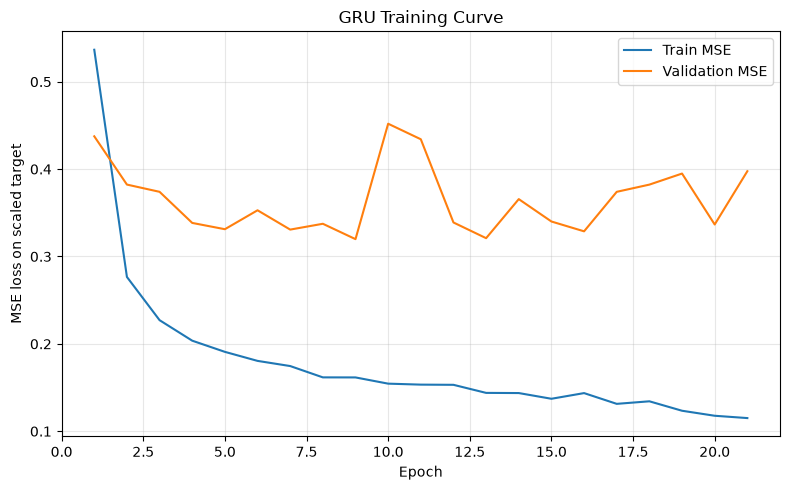

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\gru_training_curve.png


In [13]:
# =========================
# 10.1 Plot training curve
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train MSE")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE loss on scaled target")
plt.title("GRU Training Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = OUTPUT_DIR / "gru_training_curve.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

## 11. Rolling evaluation on test set

评估时不是直接输出 6 步，而是滚动生成 6 步预测：

```text
Step 1: X_t → predict FILT.NTU_{t+1}
Step 2: append predicted FILT.NTU_{t+1} into the next input → predict FILT.NTU_{t+2}
...
Step 6: predict FILT.NTU_{t+6}
```

为了保持其他特征不变，滚动时采用以下规则：

- 未来时刻的外生变量，如 `R/W NTU`, `AL_DOSE`, `R/W FLOW`，如果数据表中存在，则使用对应未来行的真实外生变量；
- 未来时刻的 `FILT. NTU` 不使用真实值，而是替换为上一步预测值；
- 如果未来行不存在，则 carry forward 上一个输入向量，并替换 `FILT. NTU`。

In [14]:
# =========================
# 11. Rolling evaluation
# =========================

def inverse_target_scaled(arr_2d):
    original_shape = arr_2d.shape
    inv = target_scaler.inverse_transform(arr_2d.reshape(-1, 1)).reshape(original_shape)
    return inv

TARGET_FEATURE_INDEX = FEATURES.index(TARGET)

def build_scaled_time_map(scaled_df: pd.DataFrame):
    times = pd.to_datetime(scaled_df["DATETIME"]).dt.floor("min")
    return {t: i for i, t in enumerate(times)}

scaled_time_to_pos = build_scaled_time_map(full_scaled)

def get_future_feature_vector_scaled(
    current_window_scaled: np.ndarray,
    future_time,
    pred_target_scaled: float,
    mode: str = "known_future",
):
    """
    Create the next input vector for rolling prediction.

    mode = "known_future":
        Use future row's exogenous variables if future_time exists.
        Replace future FILT. NTU with prediction.
    mode = "carry_forward":
        Copy the last input vector and replace FILT. NTU with prediction.
    """
    future_time = pd.Timestamp(future_time).floor("min")

    if mode == "known_future" and future_time in scaled_time_to_pos:
        next_x = full_scaled.iloc[scaled_time_to_pos[future_time]][FEATURES].to_numpy(dtype=np.float32)
    else:
        next_x = current_window_scaled[-1].copy().astype(np.float32)

    next_x[TARGET_FEATURE_INDEX] = np.float32(pred_target_scaled)
    return next_x.astype(np.float32)

def rolling_predict_one(
    model,
    x_initial_scaled: np.ndarray,
    base_time,
    horizon: int = 6,
    exog_mode: str = "known_future",
    device="cpu",
):
    """
    x_initial_scaled: [lookback, num_features]
    returns: [horizon] scaled predictions
    """
    model.eval()
    current_window = x_initial_scaled.copy().astype(np.float32)
    base_time = pd.Timestamp(base_time).floor("min")

    preds_scaled = []

    with torch.no_grad():
        for step in range(horizon):
            xb = torch.tensor(current_window[None, :, :], dtype=torch.float32).to(device)
            pred_step_scaled = model(xb).cpu().numpy().reshape(-1)[0]
            preds_scaled.append(pred_step_scaled)

            future_time = base_time + pd.Timedelta(hours=HORIZON_HOURS[step])
            next_x = get_future_feature_vector_scaled(
                current_window,
                future_time=future_time,
                pred_target_scaled=pred_step_scaled,
                mode=exog_mode,
            )
            current_window = np.vstack([current_window[1:], next_x]).astype(np.float32)

    return np.array(preds_scaled, dtype=np.float32)

def rolling_predict_batch(
    model,
    X,
    base_times,
    horizon: int = 6,
    exog_mode: str = "known_future",
    device="cpu",
):
    preds = []
    for i in range(len(X)):
        preds.append(
            rolling_predict_one(
                model,
                X[i],
                base_times[i],
                horizon=horizon,
                exog_mode=exog_mode,
                device=device,
            )
        )
    return np.stack(preds).astype(np.float32)

# Rolling multi-step prediction on test set.
y_pred_scaled = rolling_predict_batch(
    model,
    X_test,
    test_base_times,
    horizon=HORIZON,
    exog_mode=ROLLING_EXOG_MODE,
    device=device,
)

y_pred = inverse_target_scaled(y_pred_scaled)
y_true = inverse_target_scaled(y_test_multi)

metrics = []
for i, hour in enumerate(HORIZON_HOURS):
    yt = y_true[:, i]
    yp = y_pred[:, i]
    mae = mean_absolute_error(yt, yp)
    rmse = math.sqrt(mean_squared_error(yt, yp))
    r2 = r2_score(yt, yp)
    metrics.append({
        "horizon": f"t+{i+1}",
        "horizon_hour": hour,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

metrics.append({
    "horizon": "overall",
    "horizon_hour": "2-12",
    "MAE": mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1)),
    "RMSE": math.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))),
    "R2": r2_score(y_true.reshape(-1), y_pred.reshape(-1)),
})

metrics_df = pd.DataFrame(metrics)
metrics_path = OUTPUT_DIR / "gru_rolling_test_metrics.xlsx"
metrics_df.to_excel(metrics_path, index=False)

display(metrics_df)
print("Saved metrics to:", metrics_path)

,horizon,horizon_hour,MAE,RMSE,R2
0,t+1,2,0.039147,0.150836,-0.024552
1,t+2,4,0.058279,0.196552,-0.739633
2,t+3,6,0.073241,0.226923,-1.318440
3,t+4,8,0.084489,0.254846,-1.923712
4,t+5,10,0.094099,0.278862,-2.500295
5,t+6,12,0.102032,0.296043,-2.944405
6,overall,2-12,0.075215,0.239176,-1.575377


Saved metrics to: outputs\problem3\gru_rolling_baseline_v3\gru_rolling_test_metrics.xlsx


In [15]:
# =========================
# 11.1 Build test prediction long table
# =========================

test_pred_rows = []
for sample_idx in range(len(y_pred)):
    for h_idx, hour in enumerate(HORIZON_HOURS):
        test_pred_rows.append({
            "base_time": pd.Timestamp(test_base_times[sample_idx]),
            "target_time": pd.Timestamp(test_target_times[sample_idx, h_idx]),
            "horizon_hour": hour,
            "y_true": y_true[sample_idx, h_idx],
            "y_pred": y_pred[sample_idx, h_idx],
            "error": y_pred[sample_idx, h_idx] - y_true[sample_idx, h_idx],
            "abs_error": abs(y_pred[sample_idx, h_idx] - y_true[sample_idx, h_idx]),
        })

test_predictions_df = pd.DataFrame(test_pred_rows)
test_pred_path = OUTPUT_DIR / "gru_test_predictions_long.xlsx"
test_predictions_df.to_excel(test_pred_path, index=False)

display(test_predictions_df.head())
print("Saved test predictions to:", test_pred_path)

,base_time,target_time,horizon_hour,y_true,y_pred,error,abs_error
0,2026-01-23 23:00:00,2026-01-24 01:00:00,2,0.05,0.054802,0.004802,0.004802
1,2026-01-23 23:00:00,2026-01-24 03:00:00,4,0.08,0.058619,-0.021381,0.021381
2,2026-01-23 23:00:00,2026-01-24 05:00:00,6,0.08,0.059216,-0.020784,0.020784
3,2026-01-23 23:00:00,2026-01-24 07:00:00,8,0.07,0.060634,-0.009366,0.009366
4,2026-01-23 23:00:00,2026-01-24 09:00:00,10,0.07,0.004387,-0.065613,0.065613


Saved test predictions to: outputs\problem3\gru_rolling_baseline_v3\gru_test_predictions_long.xlsx


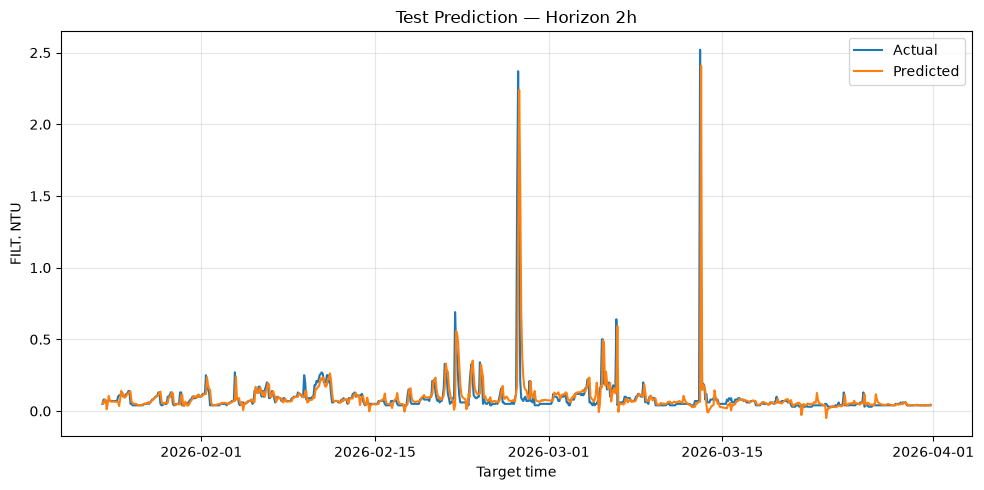

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\test_prediction_horizon_2h.png


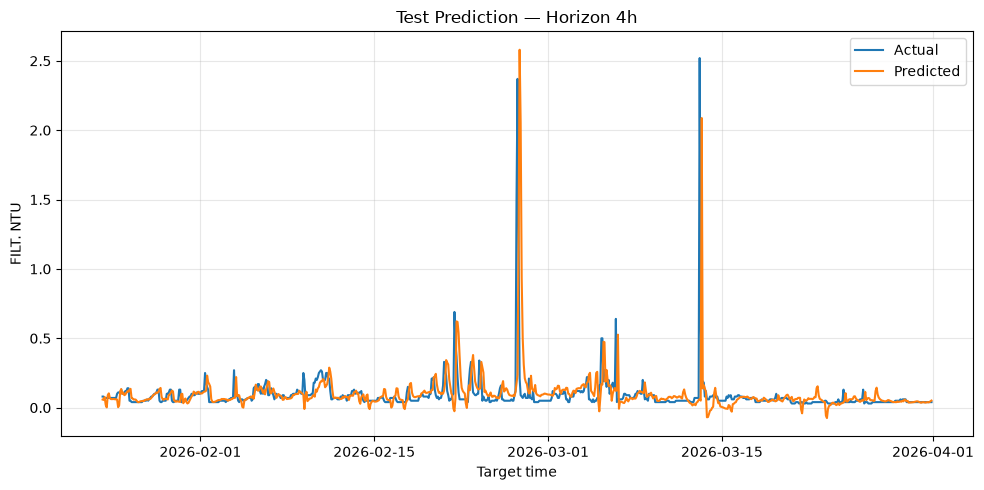

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\test_prediction_horizon_4h.png


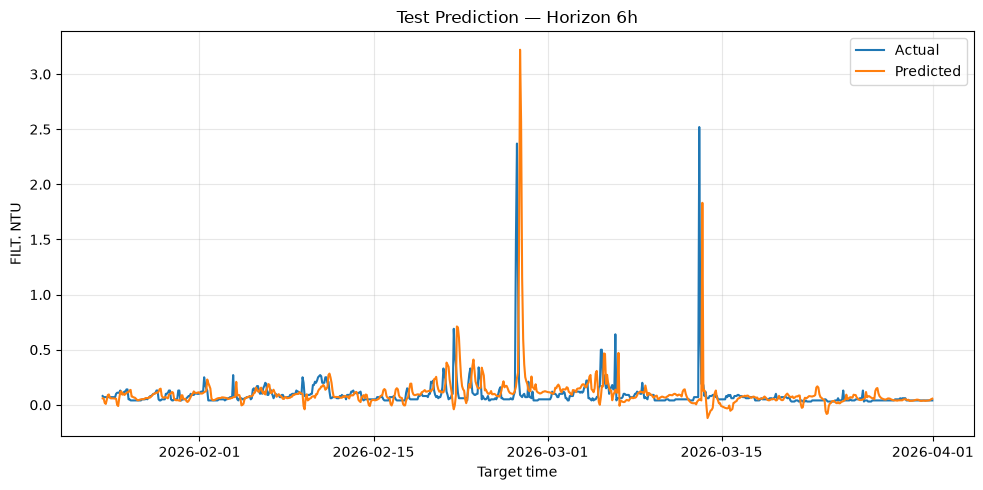

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\test_prediction_horizon_6h.png


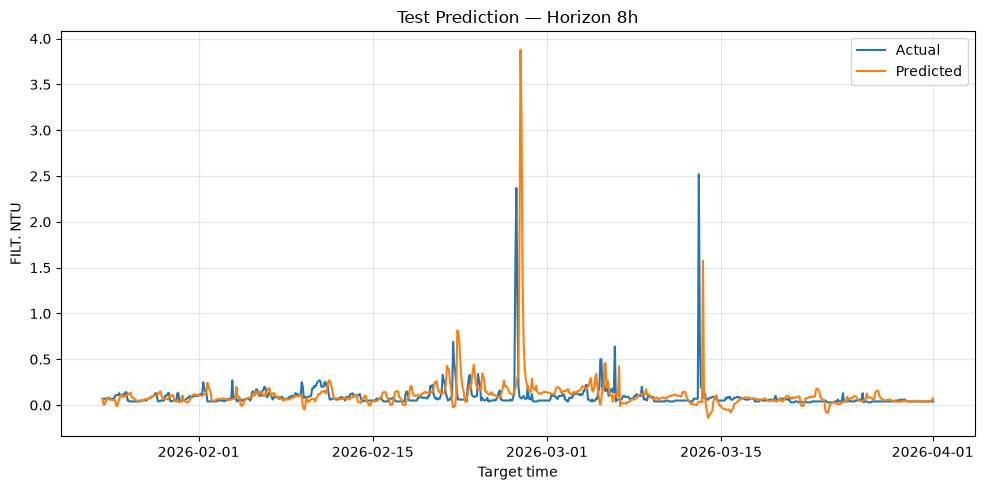

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\test_prediction_horizon_8h.png


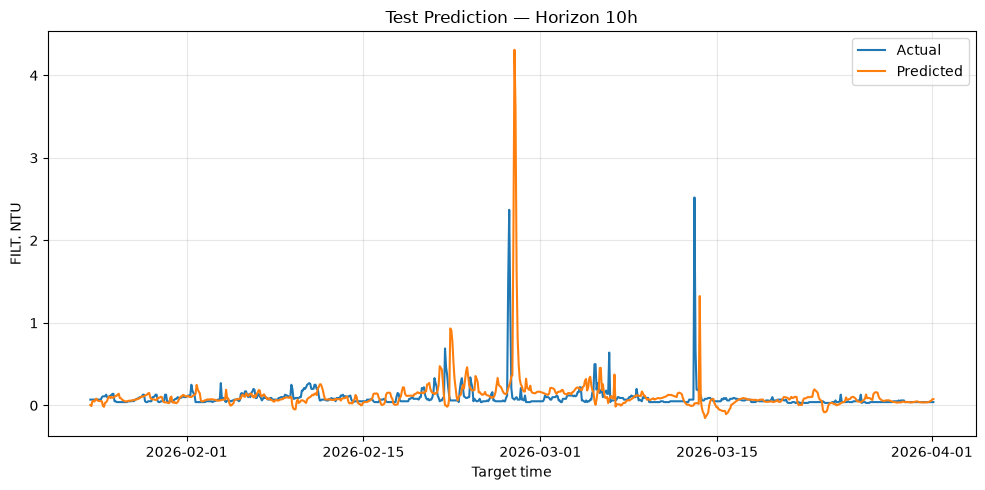

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\test_prediction_horizon_10h.png


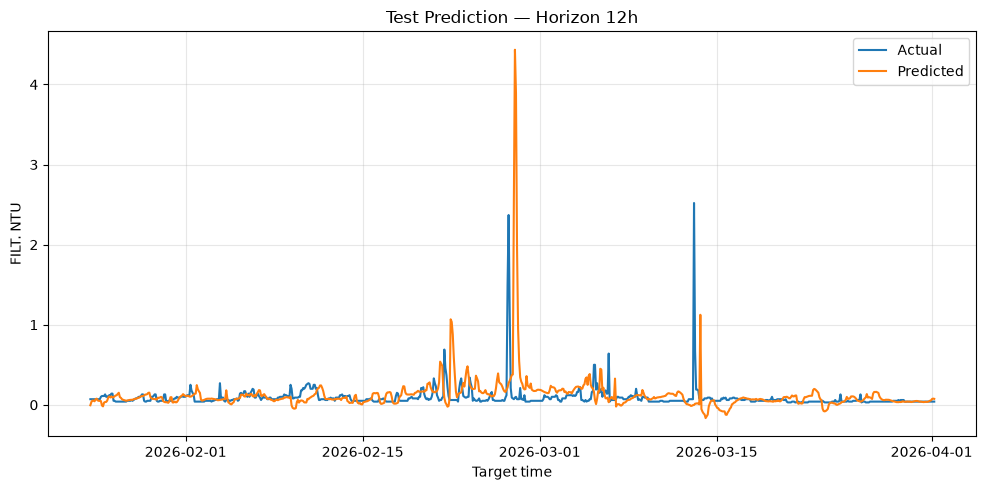

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\test_prediction_horizon_12h.png


In [16]:
# =========================
# 11.2 Plot test predictions by horizon
# =========================

for h_idx, hour in enumerate(HORIZON_HOURS):
    plot_df = pd.DataFrame({
        "target_time": pd.to_datetime(test_target_times[:, h_idx]),
        "actual": y_true[:, h_idx],
        "predicted": y_pred[:, h_idx],
    }).sort_values("target_time")

    plt.figure(figsize=(10, 5))
    plt.plot(plot_df["target_time"], plot_df["actual"], label="Actual")
    plt.plot(plot_df["target_time"], plot_df["predicted"], label="Predicted")
    plt.xlabel("Target time")
    plt.ylabel("FILT. NTU")
    plt.title(f"Test Prediction — Horizon {hour}h")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    fig_path = OUTPUT_DIR / f"test_prediction_horizon_{hour}h.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved figure to:", fig_path)

## 12. Required dates prediction

题目要求：

```text
2026-02-01, 2026-02-10, 2026-02-20
07:00 至 19:00
```

由于原始数据是 2 小时采样，可能没有精确的奇数小时，如 `07:00, 09:00, ...`。

因此本 notebook 同时输出两类表：

1. **Exact requested-time table**  
   尝试输出题目给定的 `07:00, 09:00, ..., 19:00`。如果数据中没有对应预测起点，则保留 NaN 并写明原因，不报错。

2. **Native 2-hour grid table**  
   选择最接近且不晚于 `07:00` 的可用基准时刻，例如 `06:00`，然后用 rolling prediction 输出未来 2–12 小时预测，例如 `08:00–18:00`。

所有多步结果均由单步 GRU 递归滚动得到。

In [17]:
# =========================
# 12. Prediction helper functions
# =========================

def get_time_position_map(df: pd.DataFrame):
    times = pd.to_datetime(df["DATETIME"]).dt.floor("min")
    return {t: i for i, t in enumerate(times)}

time_to_pos = get_time_position_map(full_df)

def is_continuous_time_window(times, expected_freq_hours=2):
    times = pd.to_datetime(pd.Series(times))
    diffs = times.diff().dropna()
    if len(diffs) == 0:
        return True
    return (diffs == pd.Timedelta(hours=expected_freq_hours)).all()

def predict_from_base_time(base_time, require_continuous=True, return_scaled=False):
    """
    Rolling prediction from a given base time.
    The GRU predicts one step at a time; each predicted FILT. NTU is fed back
    into the next input window.
    """
    base_time = pd.Timestamp(base_time).floor("min")
    if base_time not in time_to_pos:
        return {
            "ok": False,
            "reason": f"base_time not found: {base_time}",
            "base_time": base_time,
        }

    pos = time_to_pos[base_time]
    start_pos = pos - LOOKBACK + 1
    end_pos = pos

    if start_pos < 0:
        return {
            "ok": False,
            "reason": f"not enough lookback history before {base_time}",
            "base_time": base_time,
        }

    history_times = pd.to_datetime(full_df.iloc[start_pos:end_pos + 1]["DATETIME"]).dt.floor("min").tolist()
    if require_continuous and not is_continuous_time_window(history_times, EXPECTED_FREQ_HOURS):
        return {
            "ok": False,
            "reason": f"history window is not continuous before {base_time}",
            "base_time": base_time,
        }

    x_initial = full_scaled.iloc[start_pos:end_pos + 1][FEATURES].to_numpy(dtype=np.float32)

    pred_scaled = rolling_predict_one(
        model,
        x_initial,
        base_time=base_time,
        horizon=HORIZON,
        exog_mode=ROLLING_EXOG_MODE,
        device=device,
    )

    pred = inverse_target_scaled(pred_scaled.reshape(1, -1))[0]
    future_times = [base_time + pd.Timedelta(hours=h) for h in HORIZON_HOURS]

    return {
        "ok": True,
        "reason": "",
        "base_time": base_time,
        "future_times": future_times,
        "horizon_hours": HORIZON_HOURS,
        "predictions": pred,
        "predictions_scaled": pred_scaled if return_scaled else None,
    }

def safe_pivot_time_table(df, index_col, time_col, value_col, expected_index_values, expected_times):
    """
    Pivot without KeyError even when all predictions are NaN.
    """
    if len(df) == 0:
        pivot = pd.DataFrame({index_col: expected_index_values})
    else:
        valid_for_pivot = df.copy()
        pivot = valid_for_pivot.pivot_table(
            index=index_col,
            columns=time_col,
            values=value_col,
            aggfunc="first",
        ).reset_index()
        pivot.columns.name = None

    if index_col not in pivot.columns:
        pivot = pd.DataFrame({index_col: expected_index_values})

    for idx_value in expected_index_values:
        if idx_value not in set(pivot[index_col].astype(str)):
            extra = pd.DataFrame({index_col: [idx_value]})
            pivot = pd.concat([pivot, extra], ignore_index=True)

    for t in expected_times:
        if t not in pivot.columns:
            pivot[t] = np.nan

    pivot[index_col] = pivot[index_col].astype(str)
    pivot = pivot[[index_col] + expected_times]
    pivot = pivot.sort_values(index_col).reset_index(drop=True)
    return pivot

def choose_native_base_time(date_str, desired_time="07:00", tolerance_hours=1.1):
    """
    Choose the nearest available base time not later than desired_time within the same date.
    Example: if desired is 07:00 and available grid is 00,02,04,06,08,..., choose 06:00.
    """
    desired = pd.Timestamp(f"{date_str} {desired_time}")
    all_times = pd.to_datetime(full_df["DATETIME"]).dt.floor("min")
    same_date = all_times[all_times.dt.date == desired.date()]

    if len(same_date) == 0:
        return None, f"no timestamps found on {date_str}"

    past_or_equal = same_date[same_date <= desired]
    if len(past_or_equal) > 0:
        candidate = past_or_equal.max()
        delta_hours = abs((desired - candidate).total_seconds()) / 3600
        if delta_hours <= tolerance_hours:
            return candidate, f"chosen latest available time not later than {desired_time}"

    # Fallback: nearest available time within tolerance.
    deltas = (same_date - desired).abs()
    nearest_idx = deltas.idxmin()
    candidate = same_date.loc[nearest_idx]
    delta_hours = abs((candidate - desired).total_seconds()) / 3600
    if delta_hours <= tolerance_hours:
        return candidate, f"chosen nearest available time to {desired_time}"

    return None, f"no available base time within {tolerance_hours}h of {desired}"

In [18]:
# =========================
# 12.1 Exact requested-time table
# =========================

def build_exact_requested_prediction_table():
    rows = []

    for date_str in REQUESTED_DATES:
        # 07:00 is predicted from 05:00 with horizon 2h.
        target_0700 = pd.Timestamp(f"{date_str} 07:00")
        base_0500 = target_0700 - pd.Timedelta(hours=2)
        result_0700 = predict_from_base_time(base_0500, require_continuous=(sequence_mode == "gap_aware"))

        if result_0700["ok"]:
            rows.append({
                "date": date_str,
                "target_time": target_0700,
                "time": "07:00",
                "prediction_FILT_NTU": result_0700["predictions"][0],
                "base_time": result_0700["base_time"],
                "horizon_hour": 2,
                "status": "ok",
                "note": "07:00 predicted from 05:00 using 2h horizon",
            })
        else:
            rows.append({
                "date": date_str,
                "target_time": target_0700,
                "time": "07:00",
                "prediction_FILT_NTU": np.nan,
                "base_time": base_0500,
                "horizon_hour": 2,
                "status": "missing",
                "note": result_0700["reason"],
            })

        # 09:00–19:00 are predicted from 07:00 with direct multi-step output.
        base_0700 = pd.Timestamp(f"{date_str} 07:00")
        result = predict_from_base_time(base_0700, require_continuous=(sequence_mode == "gap_aware"))

        if result["ok"]:
            for future_time, hour, pred in zip(result["future_times"], result["horizon_hours"], result["predictions"]):
                time_label = future_time.strftime("%H:%M")
                if time_label in REQUESTED_TIMES:
                    rows.append({
                        "date": date_str,
                        "target_time": future_time,
                        "time": time_label,
                        "prediction_FILT_NTU": pred,
                        "base_time": result["base_time"],
                        "horizon_hour": hour,
                        "status": "ok",
                        "note": "Predicted from exact 07:00 using direct multi-step output",
                    })
        else:
            for time_str in REQUESTED_TIMES[1:]:
                target_time = pd.Timestamp(f"{date_str} {time_str}")
                rows.append({
                    "date": date_str,
                    "target_time": target_time,
                    "time": time_str,
                    "prediction_FILT_NTU": np.nan,
                    "base_time": base_0700,
                    "horizon_hour": int((target_time - base_0700).total_seconds() // 3600),
                    "status": "missing",
                    "note": result["reason"],
                })

    out = pd.DataFrame(rows)
    out = out.sort_values(["date", "target_time"]).reset_index(drop=True)
    return out

required_exact_df = build_exact_requested_prediction_table()

required_exact_pivot_df = safe_pivot_time_table(
    required_exact_df,
    index_col="date",
    time_col="time",
    value_col="prediction_FILT_NTU",
    expected_index_values=REQUESTED_DATES,
    expected_times=REQUESTED_TIMES,
)

display(required_exact_df[["date", "time", "base_time", "status", "note"]])
display(required_exact_pivot_df)

,date,time,base_time,status,note
0,2026-02-01,07:00,2026-02-01 05:00:00,ok,07:00 predicted from 05:00 using 2h horizon
1,2026-02-01,09:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
2,2026-02-01,11:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
3,2026-02-01,13:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
4,2026-02-01,15:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
5,2026-02-01,17:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
6,2026-02-01,19:00,2026-02-01 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
7,2026-02-10,07:00,2026-02-10 05:00:00,ok,07:00 predicted from 05:00 using 2h horizon
8,2026-02-10,09:00,2026-02-10 07:00:00,ok,Predicted from exact 07:00 using direct multi-...
9,2026-02-10,11:00,2026-02-10 07:00:00,ok,Predicted from exact 07:00 using direct multi-...


,date,07:00,09:00,11:00,13:00,15:00,17:00,19:00
0,2026-02-01,0.117422,0.118666,0.121801,0.126457,0.128876,0.138972,0.140563
1,2026-02-10,0.152042,0.165715,0.139522,0.123947,0.118757,0.096185,0.085571
2,2026-02-20,0.078451,0.090378,0.105478,0.116792,0.129041,0.148379,0.163965


In [19]:
# =========================
# 12.2 Native 2-hour grid prediction table
# =========================

def build_native_grid_prediction_table():
    rows = []

    for date_str in REQUESTED_DATES:
        base_time, base_note = choose_native_base_time(
            date_str,
            desired_time=NATIVE_GRID_START_TIME,
            tolerance_hours=NATIVE_BASE_TOLERANCE_HOURS,
        )

        if base_time is None:
            rows.append({
                "date": date_str,
                "base_time": pd.NaT,
                "target_time": pd.NaT,
                "time": None,
                "horizon_hour": np.nan,
                "prediction_FILT_NTU": np.nan,
                "status": "missing",
                "note": base_note,
            })
            continue

        result = predict_from_base_time(base_time, require_continuous=(sequence_mode == "gap_aware"))

        if result["ok"]:
            for future_time, hour, pred in zip(result["future_times"], result["horizon_hours"], result["predictions"]):
                rows.append({
                    "date": date_str,
                    "base_time": result["base_time"],
                    "target_time": future_time,
                    "time": future_time.strftime("%H:%M"),
                    "horizon_hour": hour,
                    "prediction_FILT_NTU": pred,
                    "status": "ok",
                    "note": base_note + "; native 2-hour grid output",
                })
        else:
            rows.append({
                "date": date_str,
                "base_time": base_time,
                "target_time": pd.NaT,
                "time": None,
                "horizon_hour": np.nan,
                "prediction_FILT_NTU": np.nan,
                "status": "missing",
                "note": result["reason"],
            })

    out = pd.DataFrame(rows)
    out = out.sort_values(["date", "target_time"]).reset_index(drop=True)
    return out

native_grid_df = build_native_grid_prediction_table()

native_times = sorted([t for t in native_grid_df["time"].dropna().unique().tolist()])
native_grid_pivot_df = safe_pivot_time_table(
    native_grid_df.dropna(subset=["time"]),
    index_col="date",
    time_col="time",
    value_col="prediction_FILT_NTU",
    expected_index_values=REQUESTED_DATES,
    expected_times=native_times,
)

display(native_grid_df[["date", "base_time", "target_time", "time", "horizon_hour", "prediction_FILT_NTU", "status", "note"]])
display(native_grid_pivot_df)

required_path = OUTPUT_DIR / "required_dates_predictions.xlsx"
with pd.ExcelWriter(required_path) as writer:
    required_exact_df.to_excel(writer, sheet_name="exact_requested_long", index=False)
    required_exact_pivot_df.to_excel(writer, sheet_name="exact_requested_pivot", index=False)
    native_grid_df.to_excel(writer, sheet_name="native_2h_grid_long", index=False)
    native_grid_pivot_df.to_excel(writer, sheet_name="native_2h_grid_pivot", index=False)

print("Saved required/native-grid predictions to:", required_path)

,date,base_time,target_time,time,horizon_hour,prediction_FILT_NTU,status,note
0,2026-02-01,2026-02-01 07:00:00,2026-02-01 09:00:00,09:00,2,0.118666,ok,chosen latest available time not later than 07...
1,2026-02-01,2026-02-01 07:00:00,2026-02-01 11:00:00,11:00,4,0.121801,ok,chosen latest available time not later than 07...
2,2026-02-01,2026-02-01 07:00:00,2026-02-01 13:00:00,13:00,6,0.126457,ok,chosen latest available time not later than 07...
3,2026-02-01,2026-02-01 07:00:00,2026-02-01 15:00:00,15:00,8,0.128876,ok,chosen latest available time not later than 07...
4,2026-02-01,2026-02-01 07:00:00,2026-02-01 17:00:00,17:00,10,0.138972,ok,chosen latest available time not later than 07...
5,2026-02-01,2026-02-01 07:00:00,2026-02-01 19:00:00,19:00,12,0.140563,ok,chosen latest available time not later than 07...
6,2026-02-10,2026-02-10 07:00:00,2026-02-10 09:00:00,09:00,2,0.165715,ok,chosen latest available time not later than 07...
7,2026-02-10,2026-02-10 07:00:00,2026-02-10 11:00:00,11:00,4,0.139522,ok,chosen latest available time not later than 07...
8,2026-02-10,2026-02-10 07:00:00,2026-02-10 13:00:00,13:00,6,0.123947,ok,chosen latest available time not later than 07...
9,2026-02-10,2026-02-10 07:00:00,2026-02-10 15:00:00,15:00,8,0.118757,ok,chosen latest available time not later than 07...


,date,09:00,11:00,13:00,15:00,17:00,19:00
0,2026-02-01,0.118666,0.121801,0.126457,0.128876,0.138972,0.140563
1,2026-02-10,0.165715,0.139522,0.123947,0.118757,0.096185,0.085571
2,2026-02-20,0.090378,0.105478,0.116792,0.129041,0.148379,0.163965


Saved required/native-grid predictions to: outputs\problem3\gru_rolling_baseline_v3\required_dates_predictions.xlsx


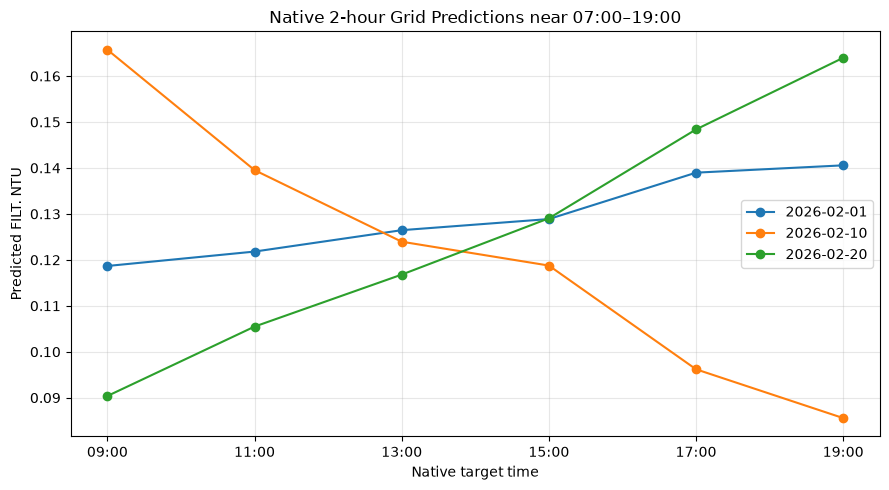

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\native_grid_predictions.png


In [20]:
# =========================
# 12.3 Plot native-grid predictions
# =========================

plot_native = native_grid_df.query("status == 'ok'").dropna(subset=["prediction_FILT_NTU"]).copy()

if len(plot_native) > 0:
    plt.figure(figsize=(9, 5))
    for date_str, group in plot_native.groupby("date"):
        group = group.sort_values("target_time")
        plt.plot(group["time"], group["prediction_FILT_NTU"], marker="o", label=date_str)

    plt.xlabel("Native target time")
    plt.ylabel("Predicted FILT. NTU")
    plt.title("Native 2-hour Grid Predictions near 07:00–19:00")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    fig_path = OUTPUT_DIR / "native_grid_predictions.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved figure to:", fig_path)
else:
    print("No native-grid predictions available to plot.")

## 13. Sensitivity analysis

题目要求分析不同输入变量对预测结果的敏感性，尤其是：

- 原水水质突变：`R/W NTU`
- 矾投加调整：`AL_DOSE`

Baseline 做法：

在保持其他变量不变的情况下，对预测基准时刻附近最后一个输入点进行比例扰动：

```text
-20%, -10%, baseline, +10%, +20%
```

然后观察未来 2–12 小时 `FILT. NTU` 预测变化。

In [21]:
# =========================
# 13. Sensitivity analysis
# =========================

SENSITIVITY_VARIABLES = ["R/W NTU", "AL_DOSE"]
SENSITIVITY_FACTORS = [0.80, 0.90, 1.00, 1.10, 1.20]

def rolling_predict_one_from_initial_window(
    x_initial_scaled: np.ndarray,
    base_time,
    horizon: int = 6,
    exog_mode: str = "known_future",
):
    return rolling_predict_one(
        model,
        x_initial_scaled,
        base_time=base_time,
        horizon=horizon,
        exog_mode=exog_mode,
        device=device,
    )

def predict_from_base_with_perturbation(
    base_time,
    perturb_variable=None,
    factor=1.0,
    perturb_last_k=1,
    require_continuous=True,
):
    base_time = pd.Timestamp(base_time).floor("min")

    if base_time not in time_to_pos:
        return {
            "ok": False,
            "reason": f"base_time not found: {base_time}",
            "base_time": base_time,
        }

    pos = time_to_pos[base_time]
    start_pos = pos - LOOKBACK + 1
    end_pos = pos

    if start_pos < 0:
        return {
            "ok": False,
            "reason": f"not enough lookback history before {base_time}",
            "base_time": base_time,
        }

    history_raw = full_df.iloc[start_pos:end_pos + 1].copy()
    history_times = pd.to_datetime(history_raw["DATETIME"]).dt.floor("min").tolist()

    if require_continuous and not is_continuous_time_window(history_times, EXPECTED_FREQ_HOURS):
        return {
            "ok": False,
            "reason": f"history window is not continuous before {base_time}",
            "base_time": base_time,
        }

    if perturb_variable is not None and perturb_variable in FEATURES:
        idx_start = max(0, len(history_raw) - perturb_last_k)
        rows_to_perturb = history_raw.index[idx_start:]

        # Important:
        # Some columns such as R/W NTU may be stored as int64.
        # Multiplying by 0.8 or 1.2 creates float values such as 9.6.
        # Pandas 2.x may raise LossySetitemError when writing float values into int64 columns.
        # Therefore, explicitly cast the perturbed column to float before assignment.
        history_raw[perturb_variable] = history_raw[perturb_variable].astype(float)
        history_raw.loc[rows_to_perturb, perturb_variable] = (
            history_raw.loc[rows_to_perturb, perturb_variable].astype(float) * float(factor)
        )
    elif perturb_variable is not None:
        return {
            "ok": False,
            "reason": f"perturb_variable not in FEATURES: {perturb_variable}",
            "base_time": base_time,
        }

    x_initial_scaled = feature_scaler.transform(history_raw[FEATURES]).astype(np.float32)

    pred_scaled = rolling_predict_one_from_initial_window(
        x_initial_scaled,
        base_time=base_time,
        horizon=HORIZON,
        exog_mode=ROLLING_EXOG_MODE,
    )

    pred = inverse_target_scaled(pred_scaled.reshape(1, -1))[0]

    return {
        "ok": True,
        "reason": "",
        "base_time": base_time,
        "future_times": [base_time + pd.Timedelta(hours=h) for h in HORIZON_HOURS],
        "horizon_hours": HORIZON_HOURS,
        "predictions": pred,
    }

def run_sensitivity_analysis():
    rows = []

    for date_str in REQUESTED_DATES:
        base_time, base_note = choose_native_base_time(
            date_str,
            desired_time=NATIVE_GRID_START_TIME,
            tolerance_hours=NATIVE_BASE_TOLERANCE_HOURS,
        )

        if base_time is None:
            rows.append({
                "date": date_str,
                "base_time": pd.NaT,
                "variable": "ALL",
                "factor": np.nan,
                "scenario": "missing",
                "horizon_hour": np.nan,
                "target_time": pd.NaT,
                "prediction_FILT_NTU": np.nan,
                "baseline_prediction": np.nan,
                "change_abs": np.nan,
                "change_pct": np.nan,
                "status": "missing",
                "note": base_note,
            })
            continue

        baseline_result = predict_from_base_with_perturbation(
            base_time,
            perturb_variable=None,
            factor=1.0,
            require_continuous=(sequence_mode == "gap_aware"),
        )

        if not baseline_result["ok"]:
            rows.append({
                "date": date_str,
                "base_time": base_time,
                "variable": "ALL",
                "factor": np.nan,
                "scenario": "missing",
                "horizon_hour": np.nan,
                "target_time": pd.NaT,
                "prediction_FILT_NTU": np.nan,
                "baseline_prediction": np.nan,
                "change_abs": np.nan,
                "change_pct": np.nan,
                "status": "missing",
                "note": baseline_result["reason"],
            })
            continue

        baseline_pred = np.array(baseline_result["predictions"])

        for var in SENSITIVITY_VARIABLES:
            for factor in SENSITIVITY_FACTORS:
                result = predict_from_base_with_perturbation(
                    base_time,
                    perturb_variable=var,
                    factor=factor,
                    perturb_last_k=1,
                    require_continuous=(sequence_mode == "gap_aware"),
                )

                if result["ok"]:
                    pred = np.array(result["predictions"])
                    for i, hour in enumerate(HORIZON_HOURS):
                        change_abs = pred[i] - baseline_pred[i]
                        change_pct = change_abs / (abs(baseline_pred[i]) + 1e-8) * 100

                        rows.append({
                            "date": date_str,
                            "base_time": base_time,
                            "variable": var,
                            "factor": factor,
                            "scenario": f"{var} x {factor:.2f}",
                            "horizon_hour": hour,
                            "target_time": base_time + pd.Timedelta(hours=hour),
                            "prediction_FILT_NTU": pred[i],
                            "baseline_prediction": baseline_pred[i],
                            "change_abs": change_abs,
                            "change_pct": change_pct,
                            "status": "ok",
                            "note": base_note + "; perturb last input step; rolling prediction",
                        })
                else:
                    rows.append({
                        "date": date_str,
                        "base_time": base_time,
                        "variable": var,
                        "factor": factor,
                        "scenario": f"{var} x {factor:.2f}",
                        "horizon_hour": np.nan,
                        "target_time": pd.NaT,
                        "prediction_FILT_NTU": np.nan,
                        "baseline_prediction": np.nan,
                        "change_abs": np.nan,
                        "change_pct": np.nan,
                        "status": "missing",
                        "note": result["reason"],
                    })

    return pd.DataFrame(rows)

sensitivity_df = run_sensitivity_analysis()

sensitivity_path = OUTPUT_DIR / "sensitivity_analysis.xlsx"
sensitivity_df.to_excel(sensitivity_path, index=False)

display(sensitivity_df.head(30))
print("Saved sensitivity analysis to:", sensitivity_path)

,date,base_time,variable,factor,scenario,horizon_hour,target_time,prediction_FILT_NTU,baseline_prediction,change_abs,change_pct,status,note
0,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,2,2026-02-01 09:00:00,0.117710,0.118666,-0.000956,-0.805945,ok,chosen latest available time not later than 07...
1,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,4,2026-02-01 11:00:00,0.120604,0.121801,-0.001198,-0.983190,ok,chosen latest available time not later than 07...
2,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,6,2026-02-01 13:00:00,0.125517,0.126457,-0.000940,-0.743706,ok,chosen latest available time not later than 07...
3,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,8,2026-02-01 15:00:00,0.127859,0.128876,-0.001017,-0.788765,ok,chosen latest available time not later than 07...
4,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,10,2026-02-01 17:00:00,0.137825,0.138972,-0.001147,-0.825026,ok,chosen latest available time not later than 07...
5,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.8,R/W NTU x 0.80,12,2026-02-01 19:00:00,0.139328,0.140563,-0.001236,-0.879133,ok,chosen latest available time not later than 07...
6,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.9,R/W NTU x 0.90,2,2026-02-01 09:00:00,0.118189,0.118666,-0.000478,-0.402489,ok,chosen latest available time not later than 07...
7,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.9,R/W NTU x 0.90,4,2026-02-01 11:00:00,0.121206,0.121801,-0.000595,-0.488588,ok,chosen latest available time not later than 07...
8,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.9,R/W NTU x 0.90,6,2026-02-01 13:00:00,0.125956,0.126457,-0.000501,-0.396351,ok,chosen latest available time not later than 07...
9,2026-02-01,2026-02-01 07:00:00,R/W NTU,0.9,R/W NTU x 0.90,8,2026-02-01 15:00:00,0.128367,0.128876,-0.000509,-0.394926,ok,chosen latest available time not later than 07...


Saved sensitivity analysis to: outputs\problem3\gru_rolling_baseline_v3\sensitivity_analysis.xlsx


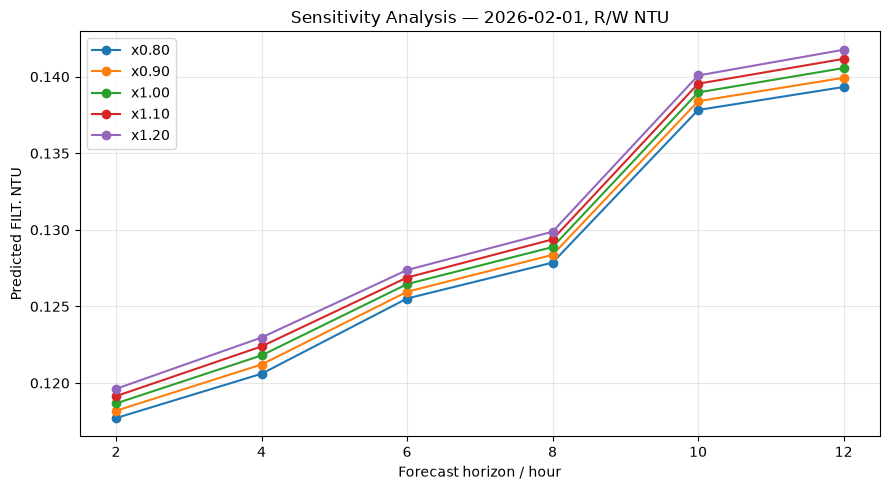

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\sensitivity_2026-02-01_RW_NTU.png


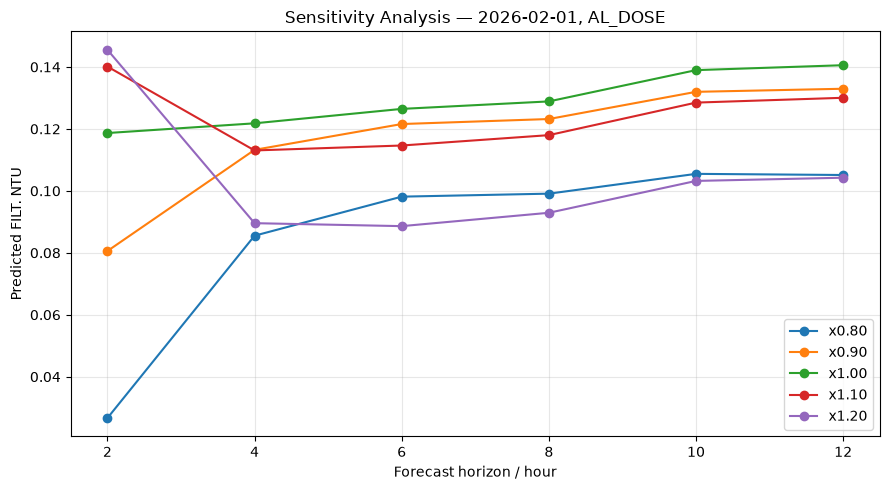

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\sensitivity_2026-02-01_AL_DOSE.png


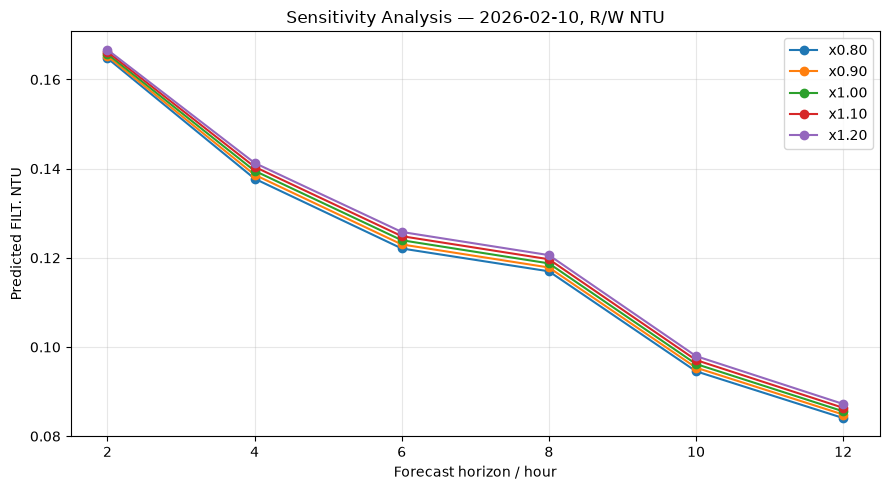

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\sensitivity_2026-02-10_RW_NTU.png


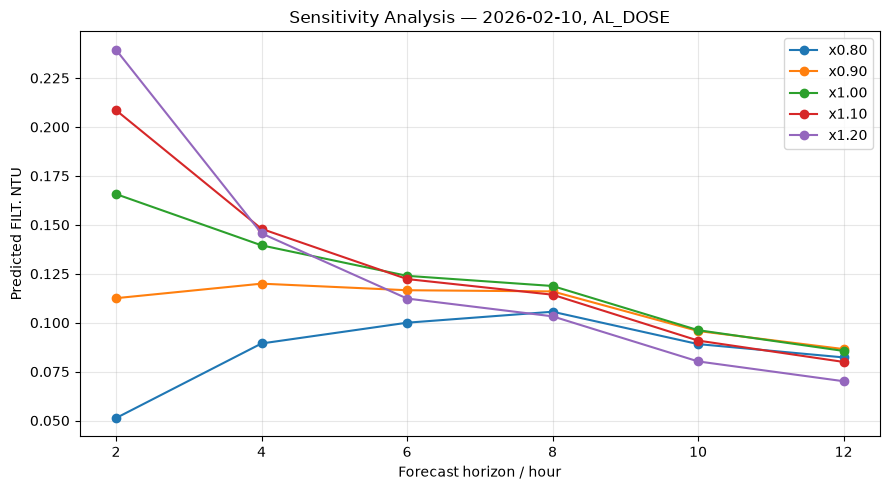

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\sensitivity_2026-02-10_AL_DOSE.png


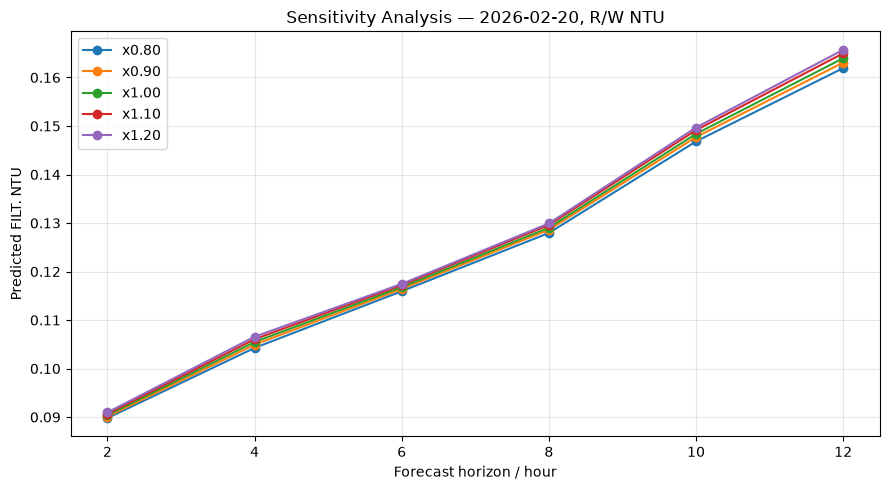

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\sensitivity_2026-02-20_RW_NTU.png


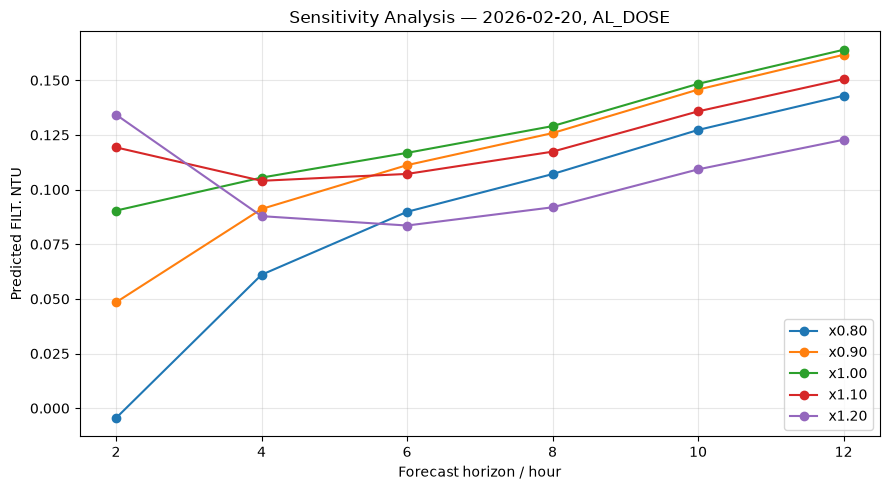

Saved figure to: outputs\problem3\gru_rolling_baseline_v3\sensitivity_2026-02-20_AL_DOSE.png


In [22]:
# =========================
# 13.1 Plot sensitivity curves
# =========================

available_sens = sensitivity_df.query("status == 'ok'").copy()

if len(available_sens) > 0:
    for date_str in REQUESTED_DATES:
        for var in SENSITIVITY_VARIABLES:
            plot_df = available_sens[
                (available_sens["date"] == date_str) &
                (available_sens["variable"] == var)
            ].copy()

            if len(plot_df) == 0:
                continue

            plt.figure(figsize=(9, 5))
            for factor, group in plot_df.groupby("factor"):
                group = group.sort_values("horizon_hour")
                plt.plot(
                    group["horizon_hour"],
                    group["prediction_FILT_NTU"],
                    marker="o",
                    label=f"x{factor:.2f}",
                )

            plt.xlabel("Forecast horizon / hour")
            plt.ylabel("Predicted FILT. NTU")
            plt.title(f"Sensitivity Analysis — {date_str}, {var}")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()

            safe_var = var.replace("/", "").replace(" ", "_")
            fig_path = OUTPUT_DIR / f"sensitivity_{date_str}_{safe_var}.png"
            plt.savefig(fig_path, dpi=300)
            plt.show()

            print("Saved figure to:", fig_path)
else:
    print("No available sensitivity results to plot.")

## 14. Export integrated Excel results

整合输出：

- `metrics`
- `test_predictions_long`
- `exact_requested_long`
- `exact_requested_pivot`
- `native_grid_long`
- `native_grid_pivot`
- `sensitivity_analysis`
- `training_history`

In [23]:
# =========================
# 14. Integrated export
# =========================

integrated_path = OUTPUT_DIR / "problem3_gru_rolling_baseline_v3_all_results.xlsx"

with pd.ExcelWriter(integrated_path) as writer:
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    test_predictions_df.to_excel(writer, sheet_name="test_predictions_long", index=False)
    required_exact_df.to_excel(writer, sheet_name="exact_requested_long", index=False)
    required_exact_pivot_df.to_excel(writer, sheet_name="exact_requested_pivot", index=False)
    native_grid_df.to_excel(writer, sheet_name="native_grid_long", index=False)
    native_grid_pivot_df.to_excel(writer, sheet_name="native_grid_pivot", index=False)
    sensitivity_df.to_excel(writer, sheet_name="sensitivity", index=False)
    history_df.to_excel(writer, sheet_name="training_history", index=False)

print("Saved integrated results to:", integrated_path)
print("Done.")

Saved integrated results to: outputs\problem3\gru_rolling_baseline_v3\problem3_gru_rolling_baseline_v3_all_results.xlsx
Done.


## 15. Suggested method description for the report

英文：

> Since the original data were recorded at a two-hour interval, hourly prediction labels cannot be directly constructed. Therefore, the future 1–12 hour forecasting task was discretized into a six-step forecasting problem, corresponding to 2, 4, 6, 8, 10 and 12 hours ahead. A rolling GRU forecasting model was developed. Instead of directly predicting all future horizons, the GRU was trained as a one-step-ahead predictor using the historical 24-hour sequence. For multi-step forecasting, the one-step prediction was recursively fed back into the input sequence as the filtered turbidity value for the next time step, and the process was repeated until the 12-hour horizon was reached. To avoid temporal leakage, the dataset was split chronologically into training, validation and testing blocks, and all scalers were fitted using the training block only.

中文：

> 由于原始数据的采样间隔为 2 小时，无法直接构造逐小时预测标签。因此，本文以 2 小时为最小预测步长，将未来 1–12 小时预测任务离散化为未来 2、4、6、8、10、12 小时的六步预测问题。本文构建了滚动式 GRU 预测模型。与直接输出全部预测步长不同，GRU 首先被训练为单步预测器，即利用过去 24 小时的输入序列预测下一时刻滤后水浊度。在进行多步预测时，将单步预测结果作为下一步输入序列中的滤后水浊度值，并递归滚动预测，直到得到未来 12 小时的结果。为避免时间泄漏，数据集按照时间顺序分块划分为训练集、验证集和测试集，且所有标准化参数均仅由训练集估计得到。

关于指定时间输出：

> 对于题目指定的 07:00–19:00 区间，若该时间点未落在原始 2 小时采样网格上，本文同时给出原生 2 小时预测网格上的结果，并在结果表中记录实际采用的预测基准时刻。